In [1]:
from pathlib import Path

# enable ipympl widgets for zoom
# %matplotlib widget
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
#from matplotlib.ticker import FixedLocator
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import pandas as pd
import pint_pandas  # needed for initialization

In [2]:
#sns.set_theme()
#sns.set_theme(style="white")
#sns.set_theme(style="whitegrid")
#sns.set_theme(style="ticks")
sns.set_theme(
    style="ticks",
    context="paper",
    rc={
        "axes.linewidth": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out"
    }
)

In [3]:
def import_dataset(filename: Path):
    df = pd.read_csv(filename, header=[0, 1])

    names = df.columns.get_level_values(0)
    units = df.columns.get_level_values(1)

    df.columns = names  # flatten
    if 'timestamp' in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], format="ISO8601")
    for col, unit in zip(names, units):  # apply units
        if unit != "No Unit":
            df[col] = df[col].astype(f"pint[{unit}]")

    return df

In [4]:
image_folder = Path.cwd() / "resources/images"
image_folder.mkdir(parents=True, exist_ok=True)
experiment_folder = Path("../data_processing")
resources_folder = experiment_folder / "resources"
df = import_dataset(resources_folder / "cr_visionfive2_data_gen.csv")

In [5]:
# Convert Pint quantities to magnitudes if necessary
plot_df = df.pint.dequantify()
plot_df.columns = plot_df.columns.get_level_values(0)

# Reshape to long format
plot_df = (
    plot_df.melt(
        id_vars=["dataset", "strength", "threading"],
        var_name="tool",
        value_name="cr",
    )
    .reset_index(drop=True)
)
plot_df = plot_df[plot_df["cr"].notna()]
#plot_df = plot_df[plot_df["threading"] == "single"]

In [7]:
def plot_tool_compare(df, dataset="text", threading="single"):
    d = df[
        (df["dataset"] == dataset) &
        (df["threading"] == threading)
    ]

    plt.figure(figsize=(7, 4))

    sns.lineplot(
        data=d,
        x="strength",
        y="cr",
        hue="tool",
        marker="o",
    )

    plt.title(f"{dataset} ({threading})")
    plt.tight_layout()
    plt.show()

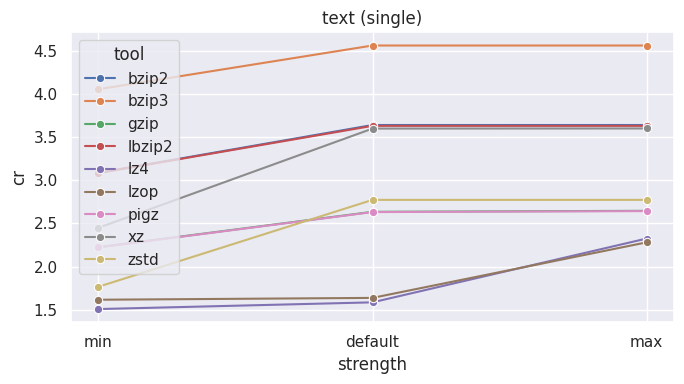

In [8]:
plot_tool_compare(plot_df, dataset="text", threading="single")

In [6]:
def plot_heatmap(df, strength="default"):
    d = df[df["strength"] == strength]

    pivot = d.pivot_table(
        index="tool",
        columns="dataset",
        values="cr",
        aggfunc="mean",
    )

    plt.figure(figsize=(6, 4))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis")

    plt.title(f"Performance heatmap ({strength})")
    plt.tight_layout()
    plt.show()

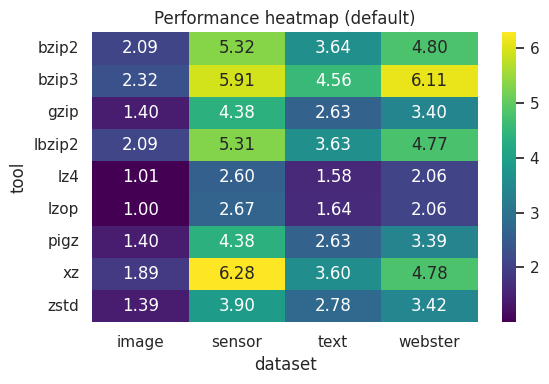

In [7]:
plot_heatmap(plot_df, strength="default")

In [258]:
def plot_faceted(df, threading):
    filtered_plot_df = df[df["threading"] == threading]
    ncols = 5
    g = sns.relplot(
        data=filtered_plot_df,
        x="strength",
        y="cr",
        hue="dataset",
        col="tool",
        col_wrap=ncols,
        kind="line",
        marker="o",
        height=2.2,
        aspect=0.65,
        facet_kws={"sharey": True},
    )
    for ax in g.axes.flat:
        ax.minorticks_on()
        ax.yaxis.set_minor_locator(MultipleLocator(0.2))

    for ax in g.axes.flat:        
        #ax.yaxis.grid(True, linestyle="-", linewidth=0.5, alpha=0.95)
        ax.grid(axis="y", which="major", linestyle="-", alpha=0.9)
        #ax.grid(axis="y", which="minor", linestyle=":", alpha=0.75)
        ax.xaxis.grid(False)
    
    for i, ax in enumerate(g.axes.flat):
        col = i % ncols
    
        # leftmost column
        if col == 0:
            ax.tick_params(labelleft=True, labelright=False)
        # rightmost column
        elif col == ncols - 1:
            ax.tick_params(labelleft=False, labelright=True)
        else:
            ax.tick_params(labelleft=False, labelright=False)    

    for ax in g.axes.flat:
        ax.set_xlabel(ax.get_xlabel(), fontsize=7)
        ax.set_ylabel(ax.get_ylabel(), fontsize=8)
        ax.tick_params(axis="x", labelsize=7)
        ax.tick_params(axis="y", labelsize=8)        
    
    # Remove the default legend (outside the figure)
    if g._legend is not None:
        g._legend.remove()

    ax = g.axes[0]
    handles, labels = ax.get_legend_handles_labels()
    
    g.figure.legend(
        handles,
        labels,
        title="Dataset",
        loc="center",
        bbox_to_anchor=(0.825, 0.3),  # adjust as needed
        frameon=True,
    )    
    # Optionally hide the axes if it is unused
    #ax.set_axis_off()

    g.set_axis_labels("strength", "compression ratio")
    g.fig.subplots_adjust(wspace=0.15, hspace=0.25)
    
    file_name = image_folder / f"compression_ratio_{threading}.pdf"
    #print("generate: %s" % file_name)
    g.fig.savefig(file_name, bbox_inches="tight")
    
    plt.show()

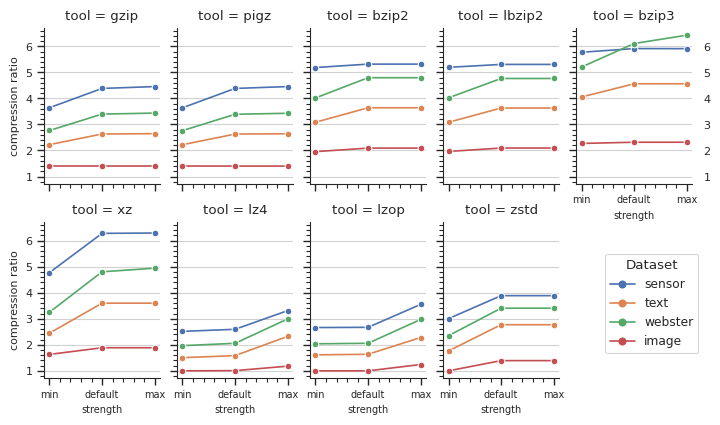

In [259]:
plot_faceted(plot_df, threading="single")